# Quantum Support Vector Data Description (QSVDD) - Results Visualization

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

plt.rcParams.update({
    'axes.grid': False,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',

    'xtick.bottom': True,
    'xtick.top': True,
    'ytick.right': True,
    'ytick.left': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.color': 'black',
    'ytick.color': 'black',

    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})


RESULTS_DIR = os.path.join("..", "results", "training")
DATA_PATH = os.path.join("..", "data", "creditcard.csv")

In [ ]:
# Load the dataset
try:
    dataframe = pd.read_csv(DATA_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(x='Class', data=dataframe, ax=axes[0], palette='viridis')
    axes[0].set_title('Transaction Class Distribution\n(0: Legitimate, 1: Fraudulent)')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Frequency')

    sns.boxplot(x='Class', y='Amount', data=dataframe, ax=axes[1], palette='viridis')
    axes[1].set_yscale('log')
    axes[1].set_title('Transaction Amount Distribution by Class (Log Scale)')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Transaction Amount (Log Scale)')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Dataset not found at {DATA_PATH}. Please verify the path.")

### Functions

In [27]:
def load_loss_history(ansatz_name, batch_size, steps, is_noisy=False):
    noise_str = "_NOISE" if is_noisy else ""
    file_name = f"{ansatz_name.upper()}_B{batch_size:02d}S{steps}{noise_str}_LOSS_HISTORY.npy"
    file_path = os.path.join(RESULTS_DIR, ansatz_name.upper(), file_name)

    try:
        return np.loadtxt(file_path)
    except FileNotFoundError:
        print(f"Warning: Could not locate {file_path}")
        return None

# Parameters based on the training script
ansatz_list = ['qcnn', 'qae', 'lcqhnn']
batch_list = [4, 4, 32]
steps_list = [2000, 2000, 250]

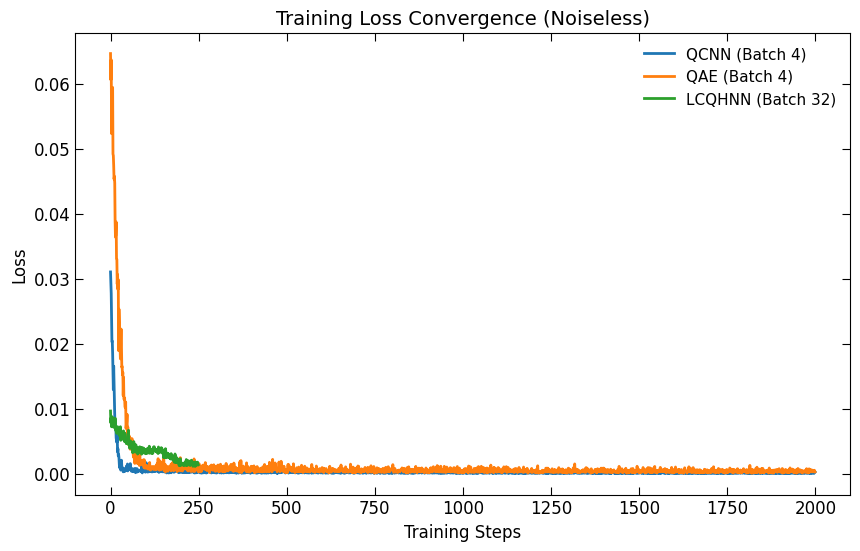

In [45]:
plt.figure(figsize=(10,6))

for i in range(len(batch_list)):
    ansatz = ansatz_list[i]
    batch = batch_list[i]
    steps = steps_list[i]

    loss_data = load_loss_history(ansatz, batch, steps, is_noisy=False)

    if loss_data is not None:
        plt.plot(loss_data, label=f'{ansatz.upper()} (Batch {batch})')

plt.title('Training Loss Convergence (Noiseless)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend(loc='best', frameon=False)
plt.show()

## Impact of Quantum Noise on Training

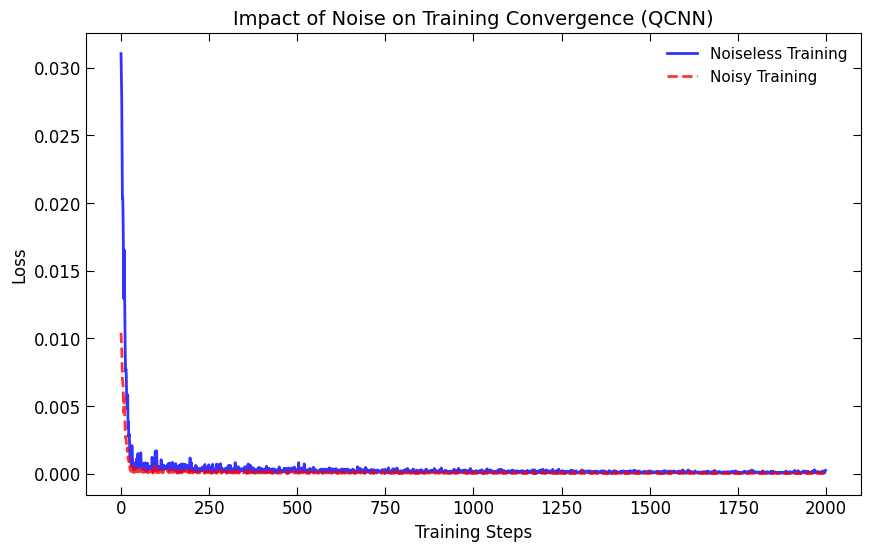

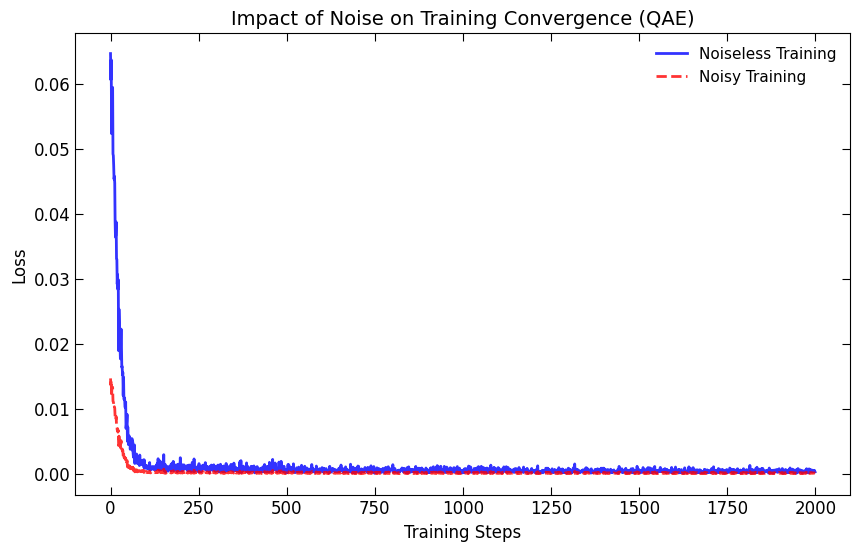

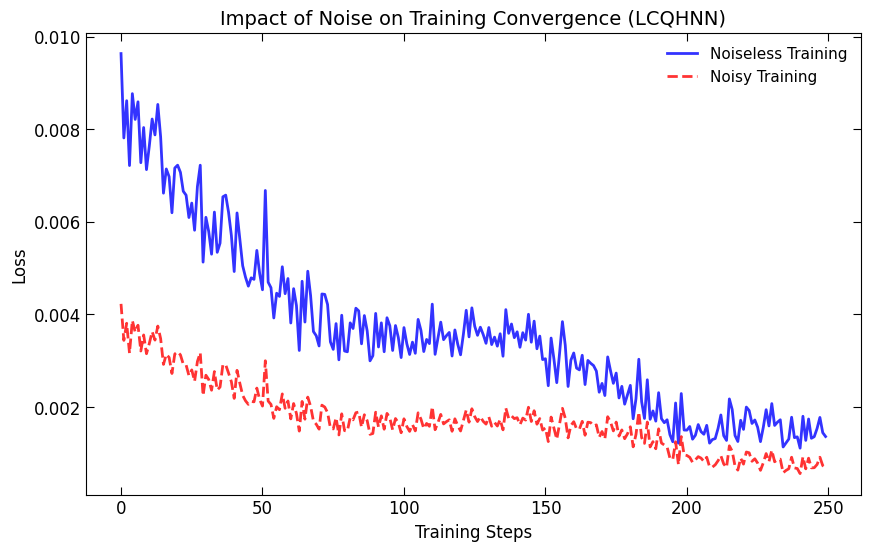

In [46]:
for i in range(len(batch_list)):

    ansatz = ansatz_list[i]
    batch = batch_list[i]
    steps = steps_list[i]

    loss_noiseless = load_loss_history(ansatz, batch, steps, is_noisy=False)
    loss_noisy = load_loss_history(ansatz, batch, steps, is_noisy=True)

    plt.figure(figsize=(10, 6))

    if loss_noiseless is not None:
        plt.plot(loss_noiseless, label='Noiseless Training', color='blue', alpha=0.8)

    if loss_noisy is not None:
        plt.plot(loss_noisy, label='Noisy Training', color='red', alpha=0.8, linestyle='--')

    plt.title(f'Impact of Noise on Training Convergence ({ansatz.upper()})')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend(loc='best', frameon=False)
    plt.show()

## Parameter Evolution over Time

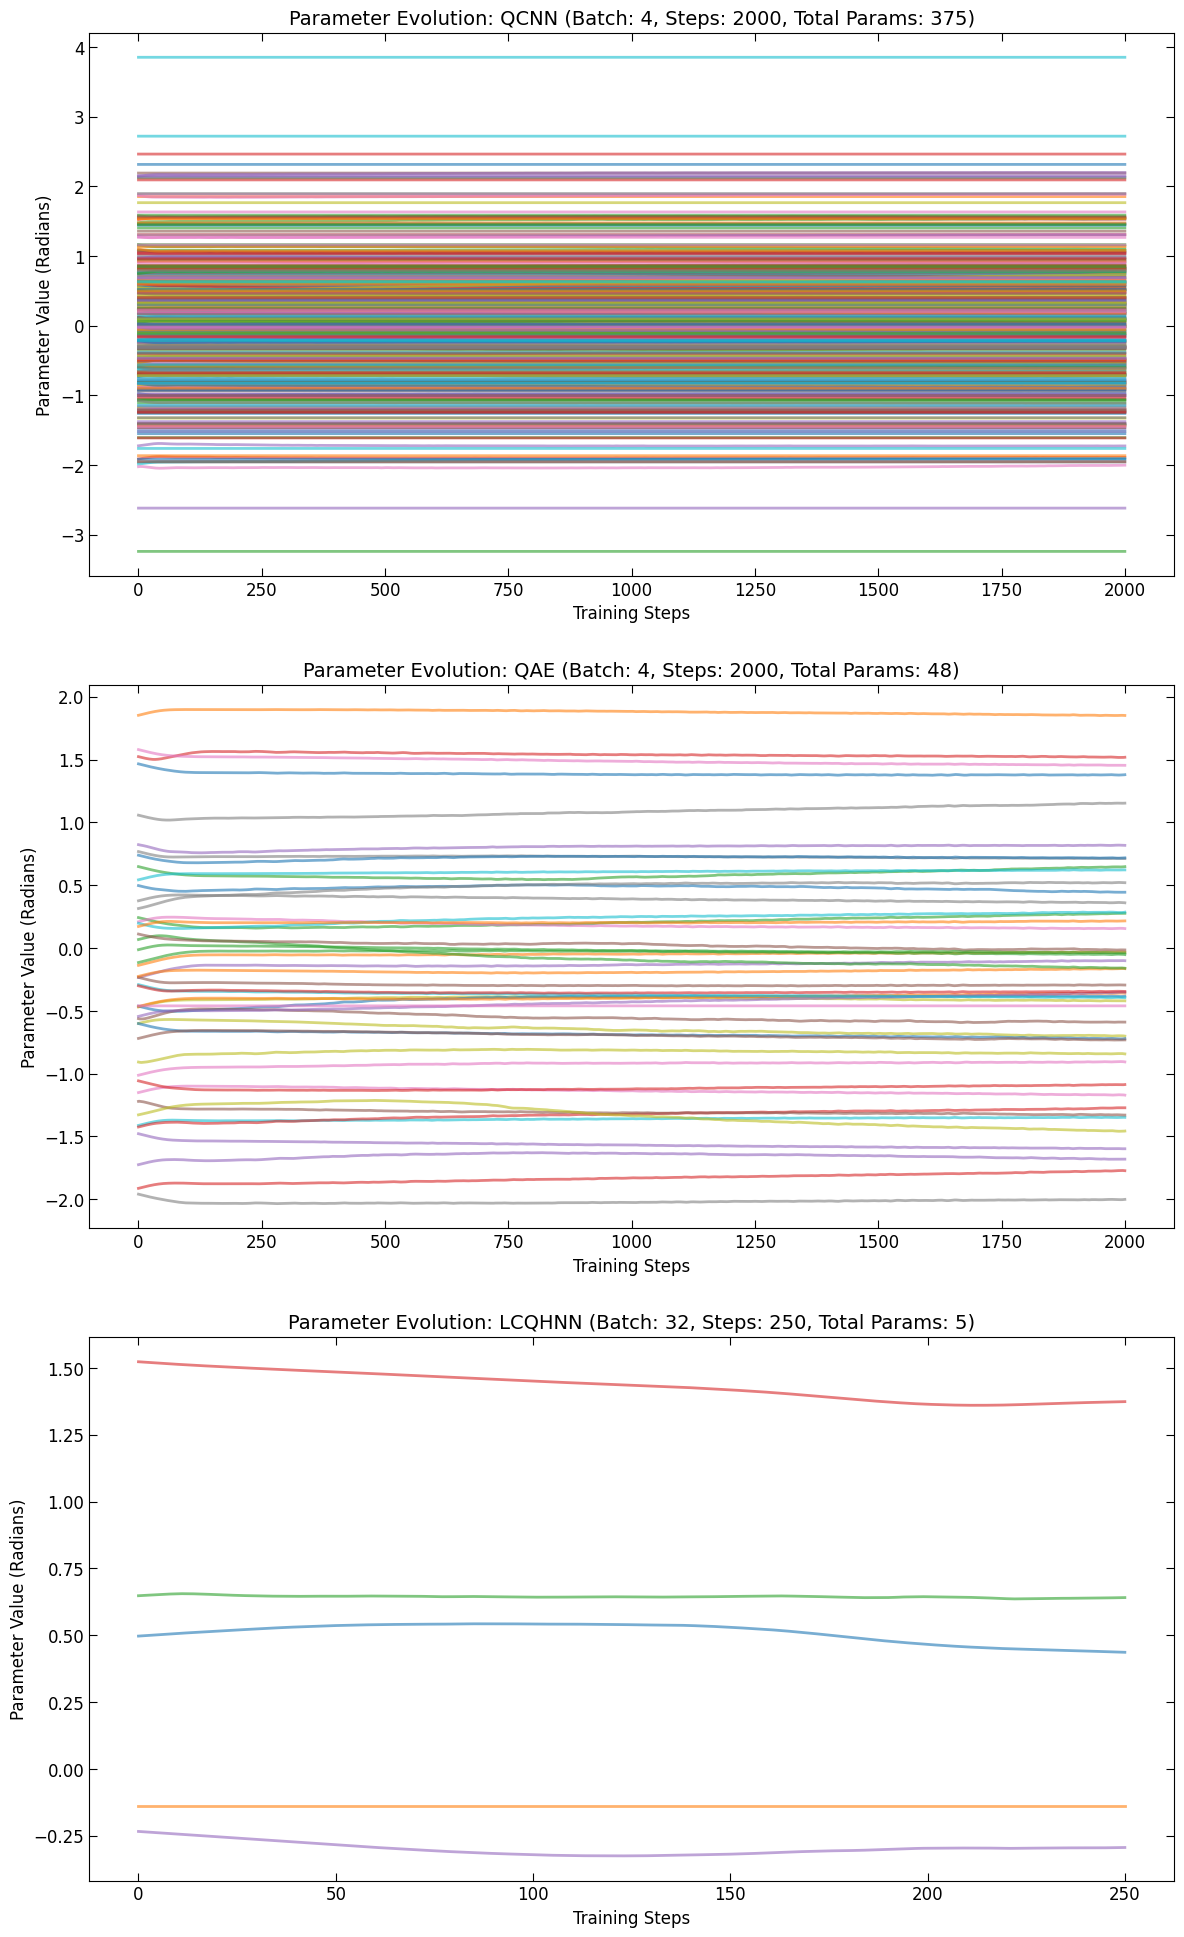

In [49]:
def load_parameter_history(ansatz_name, batch_size, steps):
    """Utility function to load parameter history arrays."""
    file_name = f"{ansatz_name.upper()}_B{batch_size:02d}S{steps}_PARAM_HISTORY.npy"
    file_path = os.path.join(RESULTS_DIR, ansatz_name.upper(), file_name)

    try:
        return np.loadtxt(file_path)
    except FileNotFoundError:
        print(f"Warning: Could not locate {file_path}")
        return None

# Define training configurations for all ansatzes with clear variable names
ansatz_configurations = [
    {'name': 'qcnn', 'batch_size': 4, 'steps': 2000, 'color': 'steelblue'},
    {'name': 'qae', 'batch_size': 4, 'steps': 2000, 'color': 'firebrick'},
    {'name': 'lcqhnn', 'batch_size': 32, 'steps': 250, 'color': 'forestgreen'}
]

figure, axes = plt.subplots(3, 1, figsize=(14, 24))

loaded_data_dictionary = {}

for index, config in enumerate(ansatz_configurations):
    ansatz_type = config['name']
    training_batch = config['batch_size']
    training_steps = config['steps']
    current_axis = axes[index]

    parameter_history_array = load_parameter_history(ansatz_type, training_batch, training_steps)
    loaded_data_dictionary[ansatz_type] = parameter_history_array

    if parameter_history_array is not None:
        total_parameters = parameter_history_array.shape[1]

        # Iterate through and plot every parameter in the array for the current ansatz
        for param_index in range(total_parameters):
            current_axis.plot(
                parameter_history_array[:, param_index],
                alpha=0.6,
            )

        current_axis.set_title(f'Parameter Evolution: {ansatz_type.upper()} (Batch: {training_batch}, Steps: {training_steps}, Total Params: {total_parameters})')
        current_axis.set_xlabel('Training Steps')
        current_axis.set_ylabel('Parameter Value (Radians)')

    else:
        current_axis.set_title(f'{ansatz_type.upper()} Parameter Data Not Found')
        current_axis.axis('off')


# Ensure subplots do not overlap and have enough breathing room
plt.show()